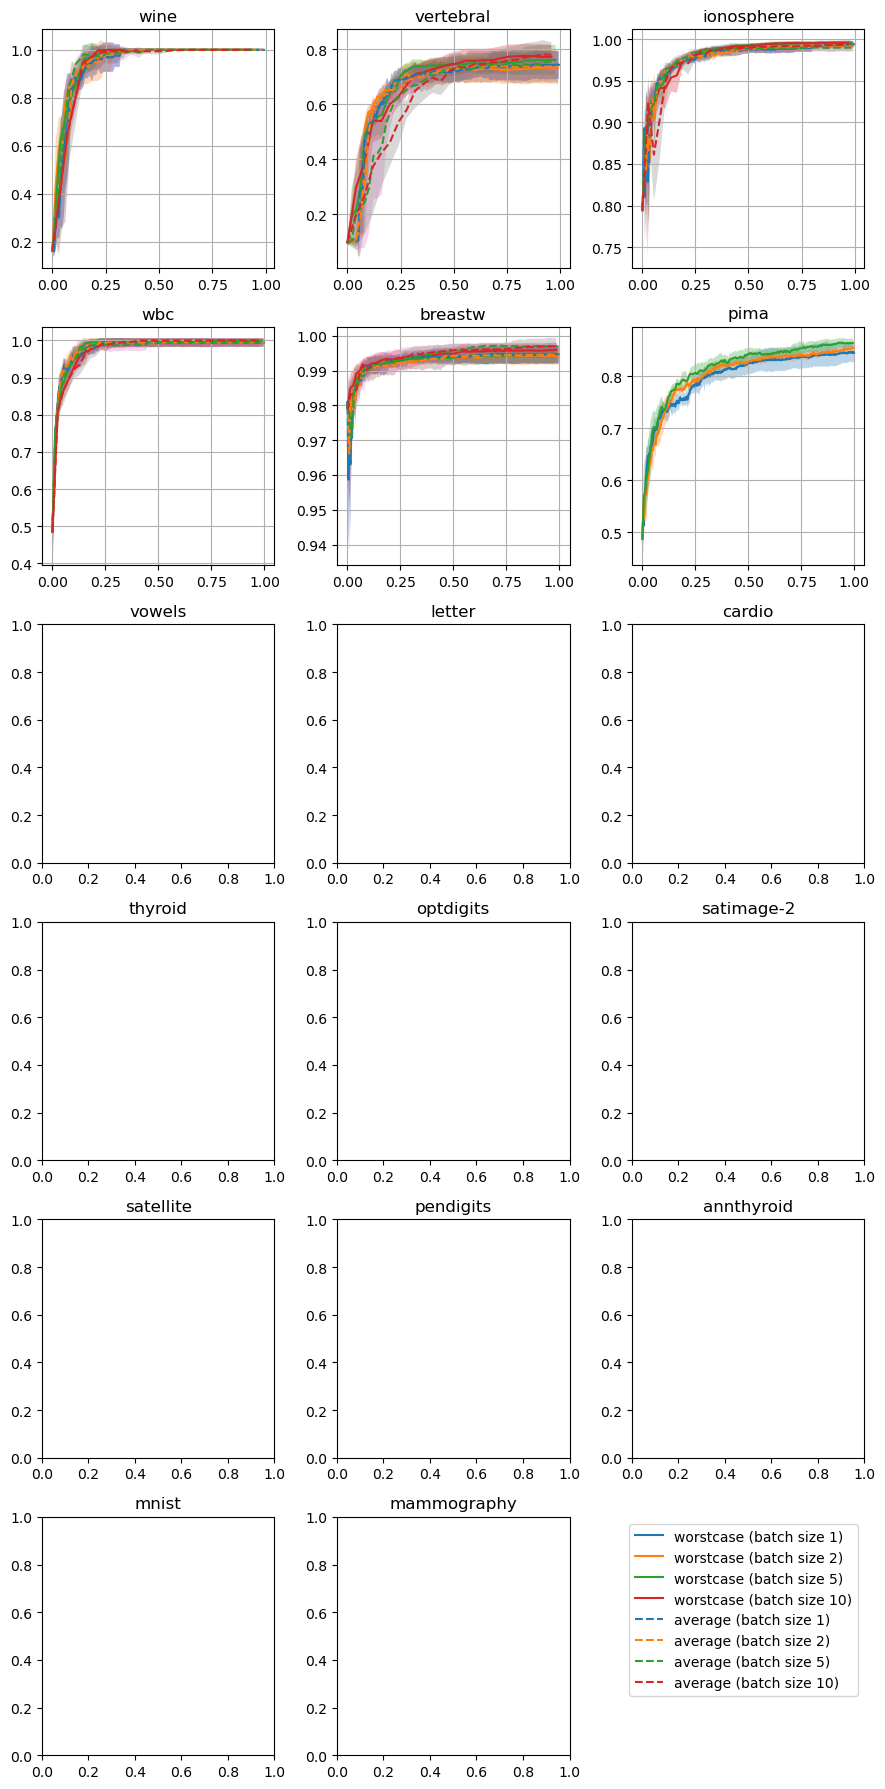

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import odds_datasets


def load_sims(dataset, batch_size, strategy):
    save_dir = f"results/{dataset}/{strategy}/batch_size_{batch_size}"
    files = (f"{save_dir}/{f}" for f in os.listdir(save_dir))
    sim = np.stack([np.load(f)["avp"] for f in files], axis=-1)
    return sim


def plot_sim(dataset, batch_sizes=[1, 2, 5, 10], strategies=["worstcase", "average"]):
    for strategy, linestyle in zip(strategies, ["-", "--", "-.", ":"]):
        for batch_size, color in zip(batch_sizes, plt.cm.tab10.colors):
            if dataset == "legend":
                label = f"{strategy} (batch size {batch_size})"
                plt.plot([], [], label=label, color=color, linestyle=linestyle)
                plt.legend()
            else:
                sim = load_sims(dataset, batch_size, strategy)
                x = np.arange(len(sim)) / len(sim)
                value = sim.mean(-1)
                lb = value - sim.std(-1)
                ub = value + sim.std(-1)
                plt.plot(x, value, color=color, linestyle=linestyle)
                plt.fill_between(x, lb, ub, alpha=0.3)
                plt.grid(True)


plt.figure(figsize=(9, 18))
for i, dataset in enumerate(odds_datasets.datasets_names):
    plt.subplot(6, 3, i + 1)
    plt.title(f"{dataset}")
    try:
        plot_sim(dataset)
    except:
        pass
plt.subplot(6, 3, 18)
plot_sim("legend")
plt.axis("off")
plt.tight_layout()
plt.savefig("results/plot.pdf")
plt.show()

In [ ]:
load_sims("vertebral", 1, "worstcase").mean(-1)
    save_dir = f"results/{dataset}/{strategy}/batch_size_{batch_size}"
    files = (f"{save_dir}/{f}" for f in os.listdir(save_dir))
    sim = np.stack([np.load(f)["avp"] for f in files], axis=-1)
    return sim